In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("data/Language Detection.csv")

In [5]:
print("Dataset Shape:", df.shape)


Dataset Shape: (10337, 2)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10337 entries, 0 to 10336
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      10337 non-null  object
 1   Language  10337 non-null  object
dtypes: object(2)
memory usage: 161.6+ KB


In [7]:
df.head(10)

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English
5,"[2] In ancient philosophy, natura is mostly us...",English
6,"[3][4] \nThe concept of nature as a whole, the...",English
7,During the advent of modern scientific method ...,English
8,"[5][6] With the Industrial revolution, nature ...",English
9,"However, a vitalist vision of nature, closer t...",English


In [8]:
df.isnull().sum()

Text        0
Language    0
dtype: int64

In [9]:
empty_rows = (
    df["Text"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print(
    "Empty Text Rows:",
    empty_rows
)

Empty Text Rows: 0


In [10]:
language_counts = df["Language"].value_counts()

print(language_counts)

Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64


In [11]:
print(
    "Total Unique Languages:",
    df["Language"].nunique()
)

Total Unique Languages: 17


In [12]:
df["text_length"] = (
    df["Text"]
    .astype(str)
    .apply(len)
)

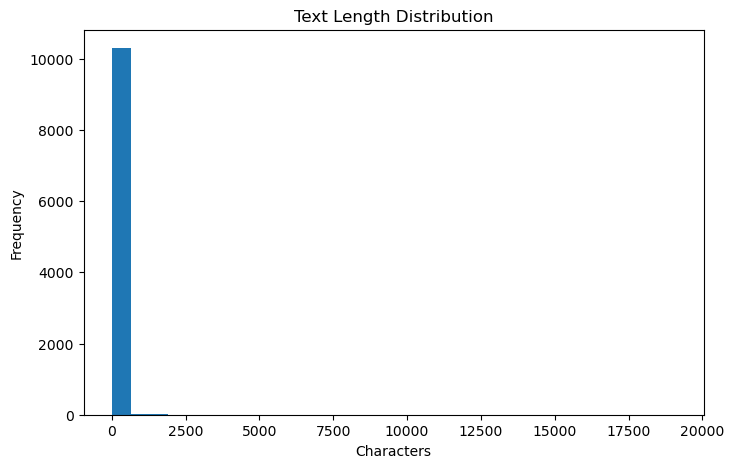

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    df["text_length"],
    bins=30
)

plt.title("Text Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [14]:
avg_length = (
    df.groupby("Language")["text_length"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_length)

Language
Hindi         1209.190476
French         145.135108
Italian        142.157593
Portugeese     139.261164
English        136.901083
Spanish        130.174603
Sweedish       118.230769
Russian        112.121387
Greek          106.260274
Tamil          105.078891
Malayalam       99.735690
Dutch           99.263736
Arabic          99.192164
Danish          91.252336
Turkish         88.487342
Kannada         87.696477
German          74.702128
Name: text_length, dtype: float64


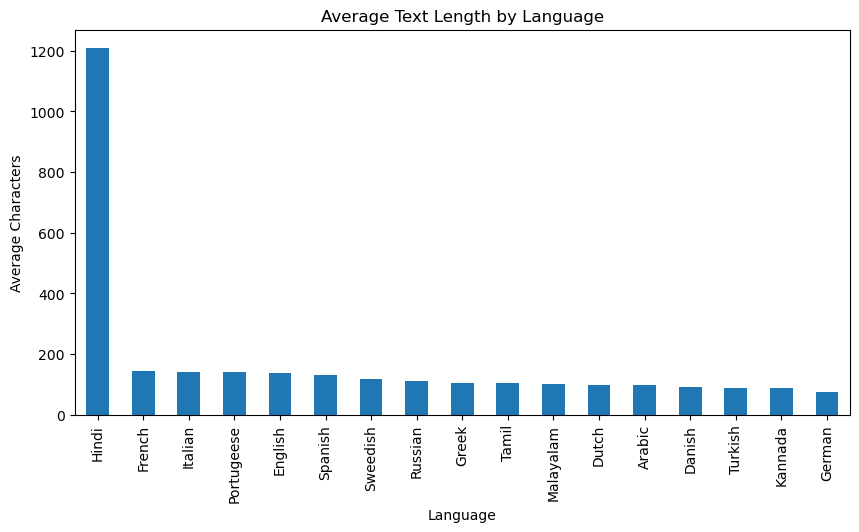

In [15]:
plt.figure(figsize=(10,5))

avg_length.plot(kind="bar")

plt.title("Average Text Length by Language")

plt.xlabel("Language")

plt.ylabel("Average Characters")

plt.show()

In [16]:
duplicates = df.duplicated().sum()

print(
    "Duplicate Rows:",
    duplicates
)

Duplicate Rows: 66


In [17]:
df = df.drop_duplicates()

In [18]:
print(df.shape)


(10271, 3)


In [19]:
avg_length

Language
Hindi         1209.190476
French         145.135108
Italian        142.157593
Portugeese     139.261164
English        136.901083
Spanish        130.174603
Sweedish       118.230769
Russian        112.121387
Greek          106.260274
Tamil          105.078891
Malayalam       99.735690
Dutch           99.263736
Arabic          99.192164
Danish          91.252336
Turkish         88.487342
Kannada         87.696477
German          74.702128
Name: text_length, dtype: float64

In [20]:
df.duplicated().sum()

0

In [21]:
import re

In [22]:
def preprocess_text(text):

    text = str(text)

    # convert to lowercase
    text = text.lower()

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [23]:
sample = "[3][4] The concept of nature as a whole, the physical universe!"

print(preprocess_text(sample))

the concept of nature as a whole the physical universe


In [24]:
df["Clean_Text"] = df["Text"].apply(preprocess_text)

In [25]:
print("Original:")
print(df["Text"].iloc[0])

print("\nCleaned:")
print(df["Clean_Text"].iloc[0])

Original:
 Nature, in the broadest sense, is the natural, physical, material world or universe.

Cleaned:
nature in the broadest sense is the natural physical material world or universe


In [26]:
clean_df = df[["Clean_Text", "Language"]]

In [27]:
clean_df.columns = ["Text", "Language"]

In [28]:
clean_df.to_csv(
    "Language_Detection_Cleaned.csv",
    index=False
)

In [29]:
clean_df.head()

,Text,Language
0,nature in the broadest sense is the natural ph...,English
1,nature can refer to the phenomena of the physi...,English
2,the study of nature is a large if not the only...,English
3,although humans are part of nature human activ...,English
4,the word nature is borrowed from the old frenc...,English


In [30]:
clean_df = pd.read_csv(
    "Language_Detection_Cleaned.csv"
)

clean_df.head()

,Text,Language
0,nature in the broadest sense is the natural ph...,English
1,nature can refer to the phenomena of the physi...,English
2,the study of nature is a large if not the only...,English
3,although humans are part of nature human activ...,English
4,the word nature is borrowed from the old frenc...,English


In [31]:
X = clean_df["Text"]

y = clean_df["Language"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

In [46]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

In [47]:
pipeline.fit(
    X_train,
    y_train
)

ValueError: np.nan is an invalid document, expected byte or unicode string.

In [38]:
clean_df.isnull().sum()

Text        2820
Language       0
dtype: int64

In [39]:
clean_df[clean_df["Text"].isnull()]

,Text,Language
1383,NaN,Malayalam
1384,NaN,Malayalam
1386,NaN,Malayalam
1387,NaN,Malayalam
1388,NaN,Malayalam
...,...,...
10265,NaN,Kannada
10266,NaN,Kannada
10267,NaN,Kannada
10268,NaN,Kannada


In [40]:
clean_df = clean_df.dropna()

In [41]:
clean_df = clean_df[
    clean_df["Text"].str.strip() != ""
]

In [42]:
clean_df.isnull().sum()

Text        0
Language    0
dtype: int64

In [43]:
X = clean_df["Text"]

y = clean_df["Language"]

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

In [52]:
pipeline.fit(
    X_train,
    y_train
)

ValueError: np.nan is an invalid document, expected byte or unicode string.

In [50]:
clean_df = pd.read_csv("Language_Detection_Cleaned.csv")

clean_df = clean_df.dropna(subset=["Text", "Language"])

clean_df["Text"] = clean_df["Text"].fillna("")

clean_df = clean_df[
    clean_df["Text"].astype(str).str.strip() != ""
]

print(clean_df.isnull().sum())
print(clean_df.shape)

Text        0
Language    0
dtype: int64
(7451, 2)


In [54]:
X = clean_df["Text"]
y = clean_df["Language"]

In [55]:
print(clean_df.shape)

(7451, 2)


In [53]:
pipeline.fit(
    X_train,
    y_train
)

ValueError: np.nan is an invalid document, expected byte or unicode string.